In [213]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [215]:
df = pd.read_csv("/SampleSuperstore.csv")

In [216]:
df.head()

,Order ID,Order Date,Category,Sub-Category,State,Region,Sales,Quantity,Discount,Profit
0,CA-1001,2024-02-22,Technology,Laptop,Illinois,East,69.52,4,0.1,-4.34
1,CA-1002,2024-10-14,Technology,Phone,Texas,South,82.93,4,0.0,-12.70
2,CA-1003,2024-12-23,Furniture,Table,Florida,Central,1186.75,1,0.1,242.95
3,CA-1004,2024-07-13,Office Supplies,Paper,California,Central,446.32,2,0.0,81.12
4,CA-1005,2024-07-12,Office Supplies,Pen,California,Central,543.75,8,0.0,-96.94


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      100 non-null    object 
 1   Order Date    100 non-null    object 
 2   Category      100 non-null    object 
 3   Sub-Category  100 non-null    object 
 4   State         100 non-null    object 
 5   Region        100 non-null    object 
 6   Sales         100 non-null    float64
 7   Quantity      100 non-null    int64  
 8   Discount      100 non-null    float64
 9   Profit        100 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 7.9+ KB


In [218]:
df.describe()

,Sales,Quantity,Discount,Profit
count,100.00000,100.000000,100.000000,100.000000
mean,1099.78750,5.160000,0.137000,87.364200
std,565.24461,2.576977,0.114287,190.939254
min,69.52000,1.000000,0.000000,-283.400000
25%,595.03000,3.000000,0.000000,-37.187500
50%,1183.67500,5.000000,0.100000,57.915000
75%,1618.20750,7.000000,0.200000,193.715000
max,1996.94000,10.000000,0.300000,595.180000


In [236]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      100 non-null    object        
 1   Order Date    100 non-null    datetime64[ns]
 2   Category      100 non-null    object        
 3   Sub-Category  100 non-null    object        
 4   State         100 non-null    object        
 5   Region        100 non-null    object        
 6   Sales         100 non-null    float64       
 7   Quantity      100 non-null    int64         
 8   Discount      100 non-null    float64       
 9   Profit        100 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 7.9+ KB


In [221]:
df.head()

,Order ID,Order Date,Category,Sub-Category,State,Region,Sales,Quantity,Discount,Profit
0,CA-1001,2024-02-22,Technology,Laptop,Illinois,East,69.52,4,0.1,-4.34
1,CA-1002,2024-10-14,Technology,Phone,Texas,South,82.93,4,0.0,-12.70
2,CA-1003,2024-12-23,Furniture,Table,Florida,Central,1186.75,1,0.1,242.95
3,CA-1004,2024-07-13,Office Supplies,Paper,California,Central,446.32,2,0.0,81.12
4,CA-1005,2024-07-12,Office Supplies,Pen,California,Central,543.75,8,0.0,-96.94


In [222]:
df['Category'].unique()

array(['Technology', 'Furniture', 'Office Supplies'], dtype=object)

In [223]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Category,0
Sub-Category,0
State,0
Region,0
Sales,0
Quantity,0
Discount,0
Profit,0


In [224]:
category_sales = (df.groupby('Category')['Sales'].sum())
category_sales

,Sales
Category,
Furniture,27931.75
Office Supplies,43584.58
Technology,38462.42


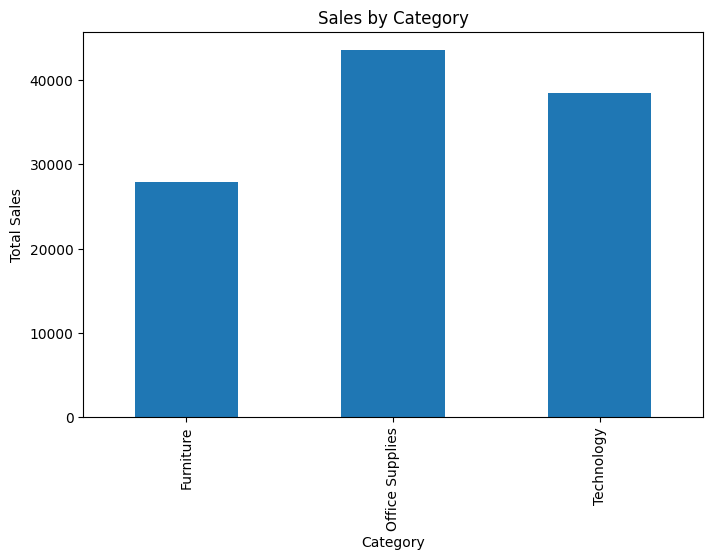

In [225]:
category_sales.plot( kind='bar',figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.show()

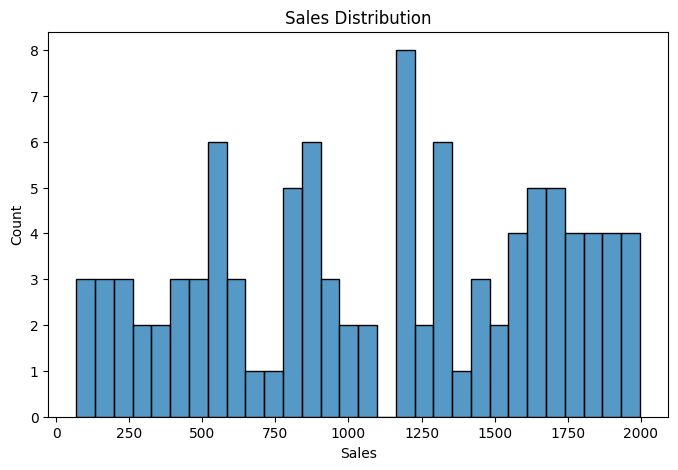

In [226]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'],bins=30)
plt.title("Sales Distribution")
plt.show()

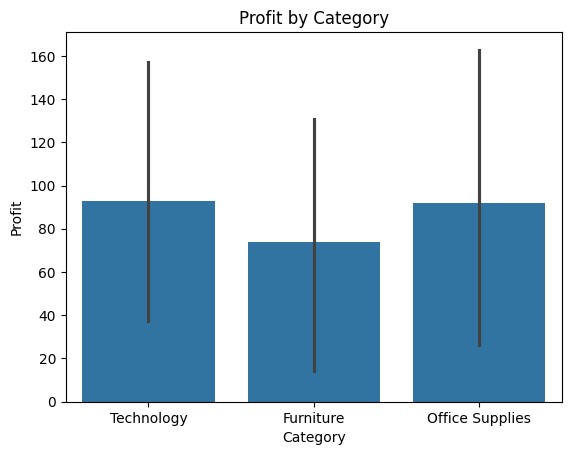

In [227]:
sns.barplot(
    data=df,
    x="Category",
    y="Profit"
)
plt.title("Profit by Category")
plt.show()

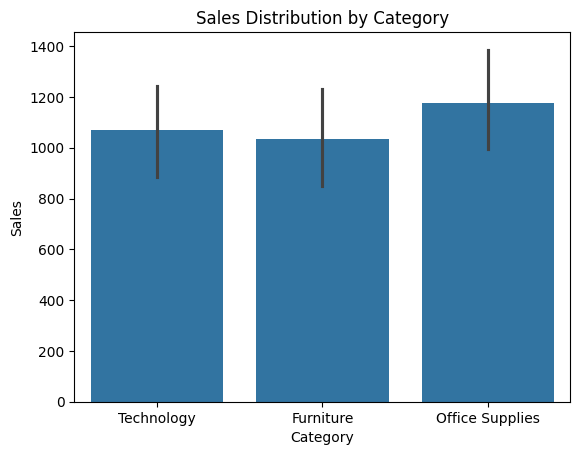

In [228]:
sns.barplot(
    data=df,
    x="Category",
    y="Sales"
)
plt.title("Sales Distribution by Category")
plt.show()

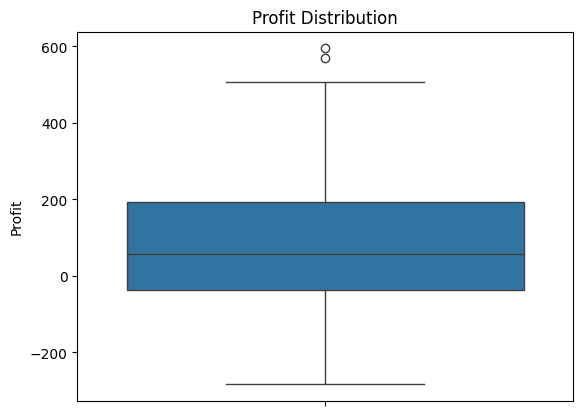

In [229]:
sns.boxplot(
    data=df,
    y="Profit"
)
plt.title("Profit Distribution")
plt.show()

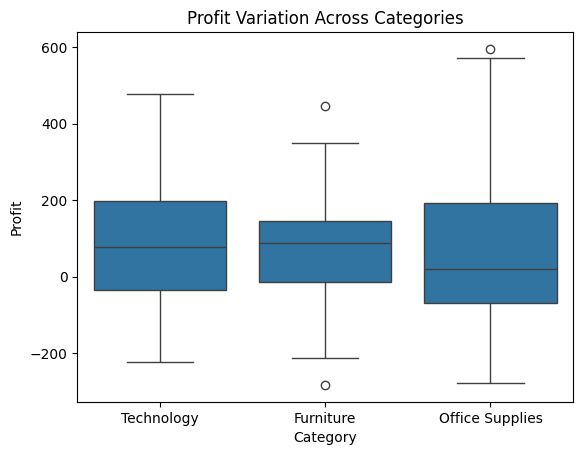

In [230]:
sns.boxplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit Variation Across Categories")
plt.show()

In [231]:
df["Discount"].unique()

array([0.1, 0. , 0.2, 0.3])

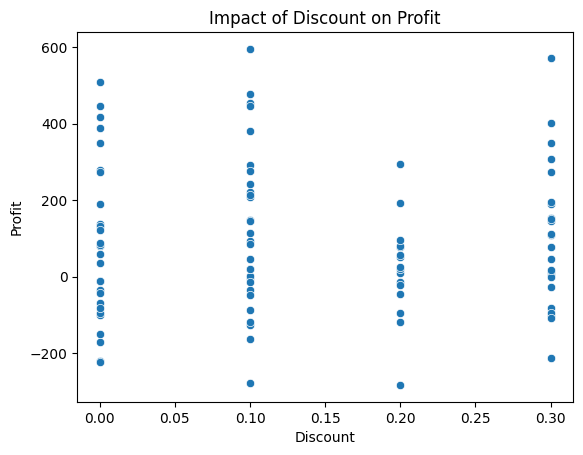

In [232]:
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Impact of Discount on Profit")
plt.show()

In [238]:
numeric_df = df.select_dtypes(
    include="number"
)

In [234]:
corr = numeric_df.corr()

corr

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.008463,-0.002657,0.312148
Quantity,0.008463,1.000000,0.106595,0.041910
Discount,-0.002657,0.106595,1.000000,-0.007484
Profit,0.312148,0.041910,-0.007484,1.000000


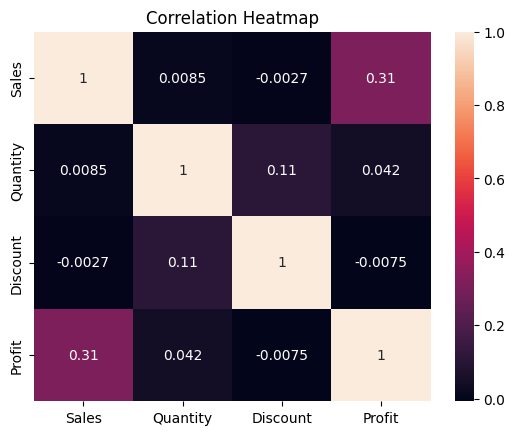

In [235]:
sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()